# Optimizing Ride Booking Conversion: Funnel Analysis for a Mobility App

### SwiftRide Product Analytics Case Study
Identifying drop-off points and behavioral patterns across the ride-booking journey.

# 1. Business Understanding

## Project Background

**SwiftRide** is a fictional ride-hailing platform operating across multiple cities in Indonesia.

Over the last quarter, the product team observed that overall ride completion rate declined from **72% to 61%**, despite relatively stable app traffic. This indicates growing friction somewhere in the ride-booking journey, potentially affecting revenue, marketplace efficiency, and customer retention.

The Product Analytics team is tasked with identifying where users abandon the booking process, understanding behavioral differences across user segments, and evaluating whether pricing experiments can improve booking conversion.

---

## Business Questions

This analysis aims to answer the following questions:

1. What is the overall ride-booking funnel conversion rate?
2. Which funnel stage has the highest drop-off?
3. Which user segments are most likely to abandon the booking process?
4. How do ETA and surge pricing affect conversion behavior?
5. Can product experiments improve booking conversion?

---

## Ride Booking Funnel

The booking journey is modeled as the following funnel:

```text
App Open
   ↓
Destination Selected
   ↓
Fare Shown
   ↓
Ride Requested
   ├── Booking Cancelled
   ↓
Driver Assigned
   ├── Booking Cancelled
   ↓
Ride Completed
```

# 2. Data Loading & Preparation

This analysis uses four relational datasets representing different levels of the ride-booking journey. Together, they enable user-level, session-level, event-level, and experiment-level analysis.

### `users.csv`
Contains user profiles and historical ride activity.

### `ride_sessions.csv`
Contains booking session information, including ETA, surge pricing, estimated fare, and user attributes.

### `ride_events.csv`
Contains event-level logs representing each stage of the ride-booking funnel.

### `experiments.csv`
Contains A/B testing assignments for pricing experiments conducted on high-surge booking sessions.

## 2.1 Import Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2.2 Load Datasets

In [51]:
events_df = pd.read_csv("../data/raw/ride_events.csv")
sessions_df = pd.read_csv("../data/raw/ride_sessions.csv")
users_df = pd.read_csv("../data/raw/users.csv")
experiments_df = pd.read_csv("../data/raw/experiments.csv")

In [52]:
# Parse datetime columns
users_df["signup_date"] = pd.to_datetime(users_df["signup_date"])

sessions_df["session_start"] = pd.to_datetime(
    sessions_df["session_start"]
)

events_df["event_time"] = pd.to_datetime(
    events_df["event_time"]
)

## 2.3 Initial Data Inspection

In [53]:
# Dataset Preview

print("Users")
display(users_df.head())

print("Ride Sessions")
display(sessions_df.head())

print("Ride Events")
display(events_df.head())

print("Experiments")
display(experiments_df.head())

Users


,user_id,signup_date,city,device_type,user_segment,total_completed_rides
0,U000001,2025-09-21,Yogyakarta,Android,Returning,26
1,U000002,2024-04-27,Surabaya,Android,Returning,41
2,U000003,2024-03-09,Bandung,Android,Returning,35
3,U000004,2024-12-12,Jakarta,Android,New,5
4,U000005,2025-04-24,Surabaya,Android,Returning,47


Ride Sessions


,session_id,user_id,session_start,city,device_type,user_segment,eta_minutes,surge_multiplier,estimated_fare,is_peak_hour
0,S0000001,U000001,2026-03-10 14:47:00,Yogyakarta,Android,Returning,7,1.11,13686,False
1,S0000002,U000001,2026-03-13 21:12:00,Yogyakarta,Android,Returning,2,1.02,12958,False
2,S0000003,U000001,2026-01-28 03:31:00,Yogyakarta,Android,Returning,3,1.24,13632,False
3,S0000004,U000001,2026-02-17 13:55:00,Yogyakarta,Android,Returning,4,1.18,13216,False
4,S0000005,U000001,2026-03-15 02:11:00,Yogyakarta,Android,Returning,4,1.24,16259,False


Ride Events


,event_id,session_id,user_id,event_name,event_time
0,E00000001,S0000001,U000001,app_open,2026-03-10 14:47:00
1,E00000002,S0000001,U000001,destination_selected,2026-03-10 14:47:30
2,E00000003,S0000001,U000001,fare_shown,2026-03-10 14:48:00
3,E00000004,S0000001,U000001,ride_requested,2026-03-10 14:48:30
4,E00000005,S0000001,U000001,driver_assigned,2026-03-10 14:49:00


Experiments


,experiment_id,session_id,variant,discount_badge_shown,conversion
0,EXP0000001,S0000008,Treatment,True,1
1,EXP0000002,S0000009,Control,False,0
2,EXP0000003,S0000010,Control,False,1
3,EXP0000004,S0000016,Treatment,True,0
4,EXP0000005,S0000017,Control,False,1


In [54]:
# Dataset Dimensions & Missing Values

missing_value = pd.DataFrame({
    "Dataset": [
        "users",
        "ride_sessions",
        "ride_events",
        "experiments"
,
    ],
    "Rows": [
        len(users_df),
        len(sessions_df),
        len(events_df),
        len(experiments_df)
    ],
    "Columns": [
        users_df.shape[1],
        sessions_df.shape[1],
        events_df.shape[1],
        experiments_df.shape[1]
    ],
    "Missing Values": [
        users_df.isna().sum().sum(),
        sessions_df.isna().sum().sum(),
        events_df.isna().sum().sum(),
        experiments_df.isna().sum().sum()
    ]
})

missing_value

,Dataset,Rows,Columns,Missing Values
0,users,50000,6,0
1,ride_sessions,425746,10,0
2,ride_events,2304820,5,0
3,experiments,120786,5,0


In [55]:
# Data Types
datasets = {
    "users": users_df,
    "ride_sessions": sessions_df,
    "ride_events": events_df,
    "experiments": experiments_df
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.dtypes.to_frame("Data Type"))


USERS


,Data Type
user_id,str
signup_date,datetime64[us]
city,str
device_type,str
user_segment,str
total_completed_rides,int64



RIDE_SESSIONS


,Data Type
session_id,str
user_id,str
session_start,datetime64[us]
city,str
device_type,str
user_segment,str
eta_minutes,int64
surge_multiplier,float64
estimated_fare,int64
is_peak_hour,bool



RIDE_EVENTS


,Data Type
event_id,str
session_id,str
user_id,str
event_name,str
event_time,datetime64[us]



EXPERIMENTS


,Data Type
experiment_id,str
session_id,str
variant,str
discount_badge_shown,bool
conversion,int64


In [56]:
# Data Integrity Checks

## Primary Key Validation
pk_validation = pd.DataFrame({
    "Dataset": [
        "users",
        "ride_sessions",
        "ride_events",
        "experiments"
    ],
    "Primary Key": [
        "user_id",
        "session_id",
        "event_id",
        "experiment_id"
    ],
    "Duplicate Records": [
        users_df["user_id"].duplicated().sum(),
        sessions_df["session_id"].duplicated().sum(),
        events_df["event_id"].duplicated().sum(),
        experiments_df["experiment_id"].duplicated().sum()
    ]
})

## Foreign Key Validation
fk_validation = pd.DataFrame({
    "Relationship": [
        "ride_sessions.user_id → users.user_id",
        "ride_events.session_id → ride_sessions.session_id",
        "ride_events.user_id → users.user_id",
        "experiments.session_id → ride_sessions.session_id"
    ],
    "Invalid References": [
        (~sessions_df["user_id"].isin(users_df["user_id"])).sum(),
        (~events_df["session_id"].isin(sessions_df["session_id"])).sum(),
        (~events_df["user_id"].isin(users_df["user_id"])).sum(),
        (~experiments_df["session_id"].isin(sessions_df["session_id"])).sum()
    ]
})

## Invalid Value Validation
invalid_values = pd.DataFrame({
    "Business Rule": [
        "ETA > 0",
        "Surge Multiplier >= 1.0",
        "Estimated Fare > 0",
        "Valid User Segment",
        "Valid Device Type",
        "Valid Event Name",
        "Binary Conversion"
    ],
    "Invalid Records": [
        (sessions_df["eta_minutes"] <= 0).sum(),
        (sessions_df["surge_multiplier"] < 1).sum(),
        (sessions_df["estimated_fare"] <= 0).sum(),
        (~users_df["user_segment"].isin(
            ["New", "Returning", "Power"]
        )).sum(),
        (~users_df["device_type"].isin(
            ["Android", "iOS"]
        )).sum(),
        (~events_df["event_name"].isin([
            "app_open",
            "destination_selected",
            "fare_shown",
            "ride_requested",
            "driver_assigned",
            "ride_completed",
            "booking_cancelled"
        ])).sum(),
        (~experiments_df["conversion"].isin([0, 1])).sum()
    ]
})

display(pk_validation)
display(fk_validation)
display(invalid_values)



,Dataset,Primary Key,Duplicate Records
0,users,user_id,0
1,ride_sessions,session_id,0
2,ride_events,event_id,0
3,experiments,experiment_id,0


,Relationship,Invalid References
0,ride_sessions.user_id → users.user_id,0
1,ride_events.session_id → ride_sessions.session_id,0
2,ride_events.user_id → users.user_id,0
3,experiments.session_id → ride_sessions.session_id,0


,Business Rule,Invalid Records
0,ETA > 0,0
1,Surge Multiplier >= 1.0,0
2,Estimated Fare > 0,0
3,Valid User Segment,0
4,Valid Device Type,0
5,Valid Event Name,0
6,Binary Conversion,0


### Initial Data Inspection Summary

The four datasets were successfully loaded and inspected.

Key observations:

- All datasets have the expected dimensions.
- No missing values were detected.
- Data types are appropriate for subsequent analysis.
- Primary keys are unique across all relational tables.
- All foreign key relationships are valid with no orphan records.
- No invalid values were found based on the defined business rules.
- The datasets are ready for exploratory analysis and funnel evaluation.

## 3. Funnel Analysis

Analyze overall funnel conversion from app open to ride completion.

### 3.1 Overall Funnel Conversion

In [62]:
# Funnel stages in order
funnel_steps = [
    "app_open",
    "destination_selected",
    "fare_shown",
    "ride_requested",
    "driver_assigned",
    "ride_completed"
]

# Count unique sessions reaching each stage
funnel_df = (
    events_df[
        events_df["event_name"].isin(funnel_steps)
    ]
    .groupby("event_name")["session_id"]
    .nunique()
    .reindex(funnel_steps)
    .reset_index()
)

funnel_df.columns = [
    "Funnel Stage",
    "Sessions"
]

funnel_df

,Funnel Stage,Sessions
0,app_open,425746
1,destination_selected,425746
2,fare_shown,425746
3,ride_requested,322582
4,driver_assigned,279254
5,ride_completed,269437


In [63]:
# Calculate Conversion Rate
funnel_df["Conversion Rate (%)"] = (
    funnel_df["Sessions"]
    / funnel_df.loc[0, "Sessions"]
    * 100
).round(2)

funnel_df

,Funnel Stage,Sessions,Conversion Rate (%)
0,app_open,425746,100.00
1,destination_selected,425746,100.00
2,fare_shown,425746,100.00
3,ride_requested,322582,75.77
4,driver_assigned,279254,65.59
5,ride_completed,269437,63.29


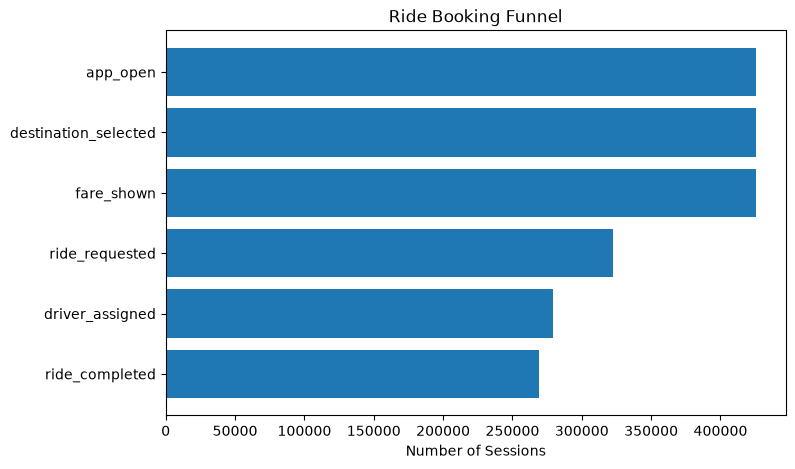

In [64]:
# Visualize Funnel
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    funnel_df["Funnel Stage"],
    funnel_df["Sessions"]
)

plt.gca().invert_yaxis()

plt.xlabel("Number of Sessions")
plt.title("Ride Booking Funnel")

plt.show()

### 3.2 Funnel Drop-off Analysis

In [65]:
dropoff_df = funnel_df.copy()

dropoff_df["Previous Stage"] = (
    dropoff_df["Sessions"].shift(1)
)

dropoff_df["Drop-off (%)"] = (
    (
        dropoff_df["Previous Stage"]
        - dropoff_df["Sessions"]
    )
    / dropoff_df["Previous Stage"]
    * 100
).round(2)

dropoff_df

,Funnel Stage,Sessions,Conversion Rate (%),Previous Stage,Drop-off (%)
0,app_open,425746,100.00,NaN,NaN
1,destination_selected,425746,100.00,425746.0,0.00
2,fare_shown,425746,100.00,425746.0,0.00
3,ride_requested,322582,75.77,425746.0,24.23
4,driver_assigned,279254,65.59,322582.0,13.43
5,ride_completed,269437,63.29,279254.0,3.52


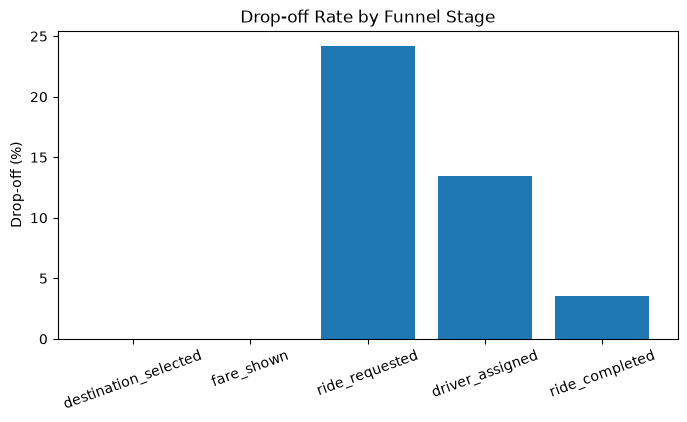

In [66]:
plt.figure(figsize=(8,4))

plt.bar(
    dropoff_df["Funnel Stage"][1:],
    dropoff_df["Drop-off (%)"][1:]
)

plt.ylabel("Drop-off (%)")
plt.title("Drop-off Rate by Funnel Stage")

plt.xticks(rotation=20)

plt.show()

### 3.3 Funnel Insights

Key findings from the funnel analysis include:

- Out of **425,746** booking sessions, **269,437** resulted in completed rides, yielding an overall ride completion rate of **63.29%**.
- The largest funnel drop-off occurred between **Fare Shown** and **Ride Requested**, where **24.23%** of users abandoned the booking before submitting a ride request. This represents the primary conversion bottleneck in the booking journey.
- A further **13.43%** of sessions dropped off before reaching **Driver Assigned**, indicating additional friction after users requested a ride.
- Once a driver was assigned, the booking process became relatively stable, with only **3.52%** of assigned rides failing to reach completion.
- Overall, the funnel suggests that the greatest opportunity to improve ride completion lies in reducing abandonment before driver assignment rather than after a driver has been matched.
- The following analyses investigate whether user segment, device type, city, ETA, surge pricing, and product experiments help explain these conversion patterns.

## 4. User Segment Analysis

Compare funnel performance across user segments.

### 4.1 Completion Rate by Segment

### 4.2 Segment Insights

## 5. Device and City Analysis

Analyze whether device type or city affects booking conversion.

### 5.1 Device Comparison

5.2 City Comparison

5.3 Insights

## 6. ETA Impact Analysis

Evaluate conversion differences between control and treatment groups.

### 6.1 ETA Distribution

### 6.2 Completion Rate by ETA Bucket

### 6.3 Insights

## 7. Surge Pricing Analysis

Perform hypothesis testing to evaluate experiment significance.

### 7.1 Surge Pricing Distribution

### 7.2 Completion Rate by Surge Bucket

### 7.3 Insights

## 8. A/B Testing Evaluation

### 8.1 Experiment Overview

### 8.2 Statistical Testing

### 8.3 Experiment Insights

## 9. Conclusions & Recommendations